In [1]:
# ============================================================
# BranchyNet + Adaptive Computation — ResNet-50 on HAM10000
# Early-Exit Inference with Confidence-Based Adaptive Depth
#
# This script merges two pieces:
#   - The early-exit / adaptive-computation architecture and
#     evaluation logic from the CIFAR-10 BranchyNet script.
#   - The HAM10000 data pipeline, training recipe, and (most
#     importantly) the METRICS JSON FORMAT from the HAM10000
#     ResNet-50 baseline script (scalar metrics at top level +
#     nested "inference_ms": {"cpu": ..., "gpu": ...}), so the
#     two JSON files stay directly comparable / mergeable.
#
# Compatible with baseline: __ham10000__baseline_resnet50.pth
# Output: __ham10000__branchynet_metrics.json
#         (same top-level schema as __ham10000__baseline_metrics.json,
#          plus BranchyNet/adaptive-computation specific fields)
#
# EXPECTED DATA STRUCTURE:
#   ./ham10000/
#       HAM10000_metadata.csv          <- official metadata CSV
#       images/                        <- all .jpg images (both parts merged)
# ============================================================

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import time, os, json, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from thop import profile

In [3]:
# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [4]:
# ── CONFIG ────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 64
NUM_CLASSES = 7
IMG_SIZE    = 224
VAL_SPLIT   = 0.2
SAVE_PATH   = "__ham10000__branchynet_resnet50.pth"

EPOCHS      = 50
LR          = 0.01
PATIENCE    = 10   # early stopping

DATA_ROOT   = "./ham10000"
CSV_PATH    = os.path.join(DATA_ROOT, "HAM10000_metadata.csv")
IMG_DIR     = os.path.join(DATA_ROOT, "images")

# Exit confidence thresholds to sweep during adaptive evaluation
EXIT_THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

# Branch loss weights — final (deepest) exit carries the most
# representational power, so it dominates the training signal.
# [exit1, exit2, final]
BRANCH_WEIGHTS = [0.2, 0.3, 0.5]

HAM10000_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

HAM10000_CLASS_NAMES = {
    "akiec": "Actinic Keratoses",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevi",
    "vasc":  "Vascular Lesions",
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

print(f"Using device : {DEVICE}")
print(f"Training     : up to {EPOCHS} epochs, early stopping patience={PATIENCE}")

Using device : cuda
Training     : up to 50 epochs, early stopping patience=10


In [5]:
# ── DATASET ────────────────────────────────────────────────────
class HAM10000Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None, class_list=HAM10000_CLASSES):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.class2idx = {cls: i for i, cls in enumerate(class_list)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        image    = Image.open(img_path).convert("RGB")
        label    = self.class2idx[row["dx"]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
# ── AUXILIARY BRANCH (early-exit classifier head) ──────────────
class EarlyExitBranch(nn.Module):
    """
    Tiny classifier head attached to an intermediate feature map.
    input_channels : number of channels from the tapped ResNet layer
    num_classes    : number of output classes
    """
    def __init__(self, input_channels: int, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(input_channels),
            nn.Linear(input_channels, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.branch(x)

In [7]:
# ── BRANCHYNET MODEL ──────────────────────────────────────────
class BranchyResNet50(nn.Module):
    """
    ResNet-50 with two auxiliary early-exit branches inserted after
    layer1 (shallow) and layer2 (mid-depth). The original final
    classifier serves as the third (deepest) exit.

    Unlike the CIFAR-10 version, the stem (conv1 + maxpool) is left
    at its standard ImageNet configuration (7x7 stride-2 conv +
    stride-2 maxpool) because HAM10000 images are resized to 224x224,
    matching the baseline ResNet-50 used in __ham10000__baseline_resnet50.pth.
    """
    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True):
        super().__init__()

        weights  = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet50(weights=weights)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)

        self.stem    = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1  = backbone.layer1   # out: 256 ch
        self.layer2  = backbone.layer2   # out: 512 ch
        self.layer3  = backbone.layer3   # out: 1024 ch
        self.layer4  = backbone.layer4   # out: 2048 ch
        self.avgpool = backbone.avgpool
        self.fc      = backbone.fc

        self.branch1 = EarlyExitBranch(256, num_classes)
        self.branch2 = EarlyExitBranch(512, num_classes)

    # ── full forward: all three exits computed (training) ─────
    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        logits1 = self.branch1(x)

        x = self.layer2(x)
        logits2 = self.branch2(x)

        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits3 = self.fc(x)

        return logits1, logits2, logits3

    # ── TRUE early-stopping adaptive forward ──────────────────
    # Computation halts as soon as the WHOLE batch is confident
    # enough at an early exit (all(conf >= tau)).
    #
    # ⚠️  Batch-wise caveat (documented honestly):
    #   This exits when the ENTIRE batch clears the threshold.
    #   A truly sample-wise implementation would require routing
    #   individual tensors through different depths — much harder
    #   on GPU and beyond the scope of this experiment. This still
    #   demonstrates meaningful speedup when most of the batch is
    #   confident early, and it gives an honest accuracy / exit-
    #   distribution trade-off for the threshold sweep.
    @torch.no_grad()
    def adaptive_forward(self, x, threshold: float = 0.8):
        """
        Returns
        -------
        logits   : Tensor (B, num_classes)
        exit_idx : Tensor (B,) — 0 = branch1, 1 = branch2, 2 = final
        """
        B = x.size(0)
        x = self.stem(x)

        # ── Exit 1 ───────────────────────────────────────────
        x = self.layer1(x)
        logits1 = self.branch1(x)
        conf1   = torch.softmax(logits1, dim=1).max(dim=1).values

        if (conf1 >= threshold).all():
            exit_idx = torch.zeros(B, dtype=torch.long, device=x.device)
            return logits1, exit_idx

        # ── Exit 2 ───────────────────────────────────────────
        x = self.layer2(x)
        logits2 = self.branch2(x)
        conf2   = torch.softmax(logits2, dim=1).max(dim=1).values

        if (conf2 >= threshold).all():
            exit_idx = torch.ones(B, dtype=torch.long, device=x.device)
            return logits2, exit_idx

        # ── Exit 3 (final) ────────────────────────────────────
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits3 = self.fc(x)

        exit_idx = torch.full((B,), 2, dtype=torch.long, device=x.device)
        exit_idx[conf2 >= threshold] = 1
        exit_idx[conf1 >= threshold] = 0

        final_logits = logits3.clone()
        mask2 = conf2 >= threshold
        final_logits[mask2] = logits2[mask2]
        mask1 = conf1 >= threshold
        final_logits[mask1] = logits1[mask1]

        return final_logits, exit_idx


model = BranchyResNet50(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters (BranchyNet): {total_params:,}")

Total parameters (BranchyNet): 23,624,277


In [8]:
# ── DATA LOADING & SPLIT ────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].drop_duplicates(subset="image_id").reset_index(drop=True)

print(f"\nDataset size: {len(df)} images")
print("\nClass distribution:")
class_counts = df["dx"].value_counts()
for cls in HAM10000_CLASSES:
    count = class_counts.get(cls, 0)
    pct   = count / len(df) * 100
    print(f"  {cls:<8} ({HAM10000_CLASS_NAMES[cls]:<25}): {count:>5} ({pct:.1f}%)")

train_df, val_df = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED, stratify=df["dx"]
)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")


Dataset size: 10015 images

Class distribution:
  akiec    (Actinic Keratoses        ):   327 (3.3%)
  bcc      (Basal Cell Carcinoma     ):   514 (5.1%)
  bkl      (Benign Keratosis         ):  1099 (11.0%)
  df       (Dermatofibroma           ):   115 (1.1%)
  mel      (Melanoma                 ):  1113 (11.1%)
  nv       (Melanocytic Nevi         ):  6705 (66.9%)
  vasc     (Vascular Lesions         ):   142 (1.4%)

Train: 8012 | Val: 2003


In [9]:
# ── TRANSFORMS ───────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [10]:
# ── WEIGHTED SAMPLER (class imbalance) ──────────────────────────
# Sampler ONLY — no weighted loss on top (avoids double correction)
class2idx      = {cls: i for i, cls in enumerate(HAM10000_CLASSES)}
train_labels   = train_df["dx"].map(class2idx).values
class_counts_  = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / (class_counts_ + 1e-6)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_labels),
    replacement = True,
    generator   = g,
)

In [11]:
# ── DATALOADERS ────────────────────────────────────────────────
train_set = HAM10000Dataset(train_df, IMG_DIR, transform=transform_train)
val_set   = HAM10000Dataset(val_df,   IMG_DIR, transform=transform_val)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          sampler=sampler,
                          num_workers=0,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=0,
                          worker_init_fn=seed_worker)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 126 | Val batches: 32


In [12]:
# ── LOSS & OPTIMIZER ─────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.SGD(
    model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-5
)

def branchynet_loss(logits_list, labels, weights=BRANCH_WEIGHTS):
    """Weighted sum of losses from all exit heads."""
    assert len(logits_list) == len(weights), "Mismatch between exits and weights"
    total = sum(w * criterion(logits, labels)
                for w, logits in zip(weights, logits_list))
    return total

In [13]:
# ── TRAINING HELPERS ────────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits1, logits2, logits3 = model(inputs)
        loss = branchynet_loss([logits1, logits2, logits3], labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += logits3.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate_standard(model, loader):
    """Standard accuracy using only the final exit (no early stopping)."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            _, _, logits3 = model(inputs)
            correct += logits3.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total

In [14]:
# ── TRAINING LOOP ────────────────────────────────────────────
best_val_acc                       = 0.0
no_improve                         = 0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*60)
print("TRAINING — BranchyNet (3 exits) on HAM10000")
print("="*60)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_acc         = evaluate_standard(model, val_loader)
    scheduler.step(val_acc)

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        no_improve = 0
        marker = " <- best saved"
    else:
        no_improve += 1
        marker = f" (no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest validation accuracy (final exit): {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING — BranchyNet (3 exits) on HAM10000
Epoch  1/50 | Loss: 1.5416 | Train: 0.5836 | Val: 0.6905 <- best saved
Epoch  2/50 | Loss: 1.2790 | Train: 0.7609 | Val: 0.7099 <- best saved
Epoch  3/50 | Loss: 1.1877 | Train: 0.8020 | Val: 0.7564 <- best saved
Epoch  4/50 | Loss: 1.1322 | Train: 0.8351 | Val: 0.7334 (no improve 1/10)
Epoch  5/50 | Loss: 1.0874 | Train: 0.8603 | Val: 0.7464 (no improve 2/10)
Epoch  6/50 | Loss: 1.0556 | Train: 0.8719 | Val: 0.8103 <- best saved
Epoch  7/50 | Loss: 1.0202 | Train: 0.8864 | Val: 0.7743 (no improve 1/10)
Epoch  8/50 | Loss: 0.9927 | Train: 0.9006 | Val: 0.8303 <- best saved
Epoch  9/50 | Loss: 0.9748 | Train: 0.9021 | Val: 0.8477 <- best saved
Epoch 10/50 | Loss: 0.9605 | Train: 0.9119 | Val: 0.7913 (no improve 1/10)
Epoch 11/50 | Loss: 0.9404 | Train: 0.9180 | Val: 0.8283 (no improve 2/10)
Epoch 12/50 | Loss: 0.9269 | Train: 0.9284 | Val: 0.8447 (no improve 3/10)
Epoch 13/50 | Loss: 0.9145 | Train: 0.9302 | Val: 0.8043 (no improve 4/10)
Epoc

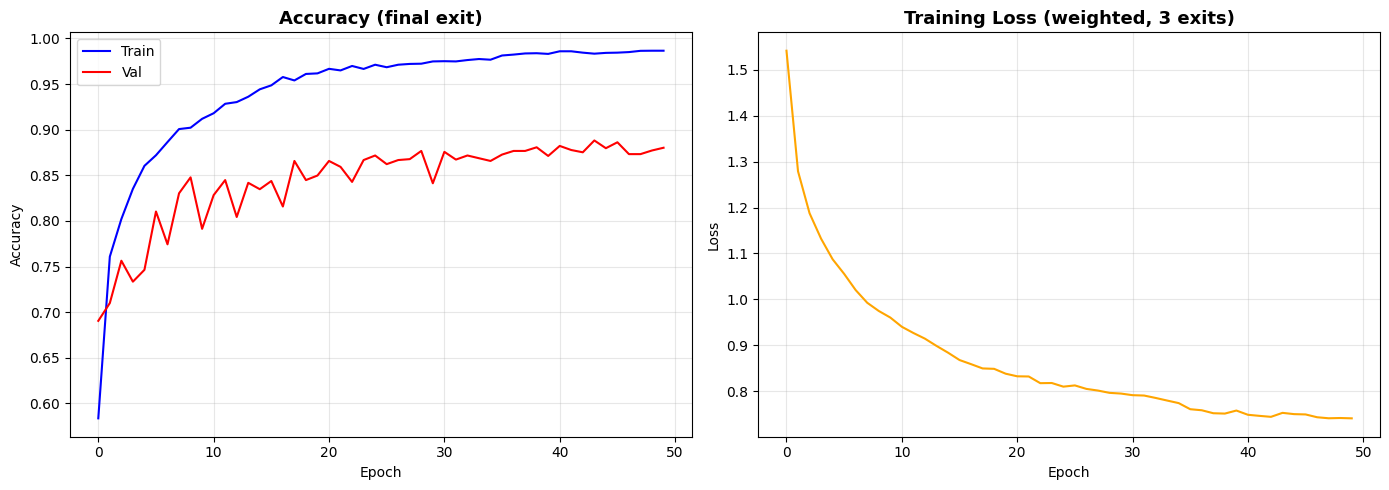

In [15]:
# ── TRAINING CURVES ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_accs, label="Train", color="blue")
ax1.plot(val_accs,   label="Val",   color="red")
ax1.set_title("Accuracy (final exit)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color="orange")
ax2.set_title("Training Loss (weighted, 3 exits)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("__ham10000__branchynet_training_curves.png", dpi=150)
plt.show()

In [5]:
# ── FULL EVALUATION (final exit only) ──────────────────────────
print("\n" + "="*60)
print("FULL EVALUATION — final exit (no early stopping)")
print("="*60)

model = BranchyResNet50(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        _, _, logits3 = model(inputs)
        preds = logits3.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall    = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1        = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report (final exit):")
print(classification_report(all_labels, all_preds,
                             target_names=HAM10000_CLASSES, digits=4))


FULL EVALUATION — final exit (no early stopping)


NameError: name 'BranchyResNet50' is not defined

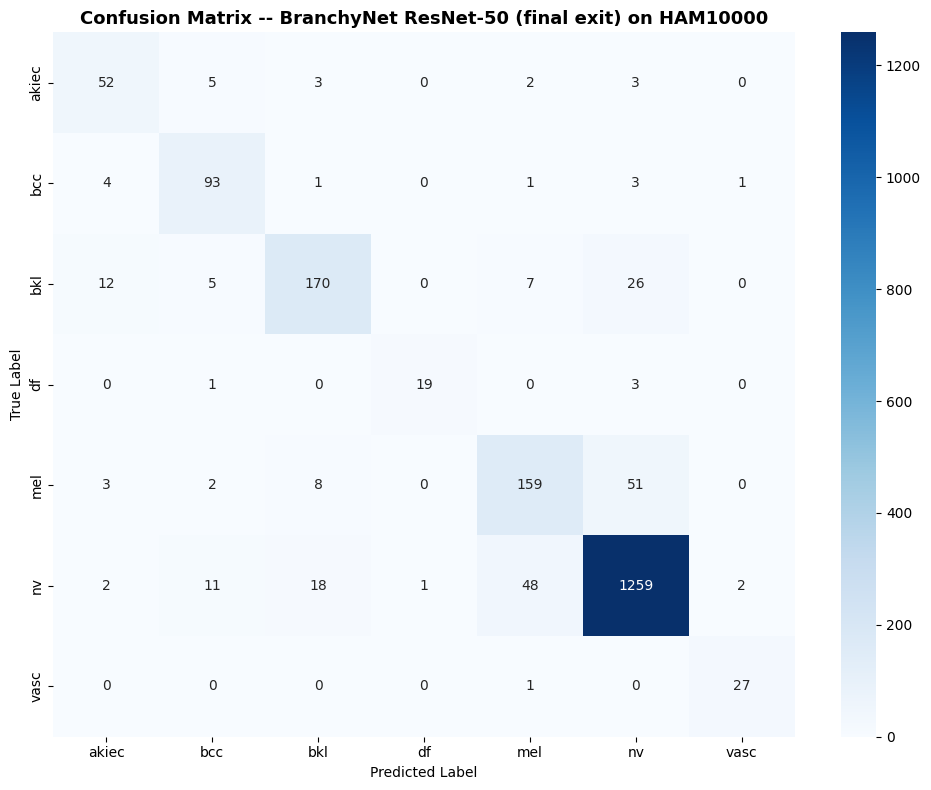

In [17]:
# ── CONFUSION MATRIX (final exit) ───────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=HAM10000_CLASSES, yticklabels=HAM10000_CLASSES)
plt.title("Confusion Matrix -- BranchyNet ResNet-50 (final exit) on HAM10000",
          fontsize=13, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("__ham10000__branchynet_confusion_matrix.png", dpi=150)
plt.show()

In [18]:
# ── ADAPTIVE COMPUTATION EVALUATION ─────────────────────────────
print("\n" + "="*60)
print("ADAPTIVE COMPUTATION — Early-Exit Threshold Sweep")
print("="*60)
print(f"  Thresholds tested: {EXIT_THRESHOLDS}")

adaptive_results = []

for tau in EXIT_THRESHOLDS:
    preds_list, labels_list, exit_idx_list = [], [], []

    t_start = time.time()
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            logits, exit_idx = model.adaptive_forward(inputs, threshold=tau)
            preds_list.extend(logits.argmax(1).cpu().numpy())
            labels_list.extend(labels.numpy())
            exit_idx_list.extend(exit_idx.cpu().numpy())
    t_end = time.time()

    preds_arr    = np.array(preds_list)
    labels_arr   = np.array(labels_list)
    exit_idx_arr = np.array(exit_idx_list)
    n            = len(labels_arr)

    acc_t  = accuracy_score(labels_arr, preds_arr)
    prec_t = precision_score(labels_arr, preds_arr, average="macro", zero_division=0)
    rec_t  = recall_score(labels_arr, preds_arr, average="macro", zero_division=0)
    f1_t   = f1_score(labels_arr, preds_arr, average="macro", zero_division=0)

    frac_exit1  = (exit_idx_arr == 0).mean()
    frac_exit2  = (exit_idx_arr == 1).mean()
    frac_exit3  = (exit_idx_arr == 2).mean()
    avg_time_ms = (t_end - t_start) / n * 1000

    adaptive_results.append({
        "threshold"  : tau,
        "accuracy"   : round(acc_t,  6),
        "precision"  : round(prec_t, 6),
        "recall"     : round(rec_t,  6),
        "f1"         : round(f1_t,   6),
        "frac_exit1" : round(frac_exit1, 4),
        "frac_exit2" : round(frac_exit2, 4),
        "frac_exit3" : round(frac_exit3, 4),
        "avg_time_ms": round(avg_time_ms, 4),
    })

    print(f"  τ={tau:.2f} | Acc={acc_t:.4f} | F1={f1_t:.4f} | "
          f"Exit1={frac_exit1:.1%} Exit2={frac_exit2:.1%} Exit3={frac_exit3:.1%} | "
          f"Time={avg_time_ms:.4f}ms/sample")

best_adaptive = max(adaptive_results, key=lambda r: r["accuracy"])


ADAPTIVE COMPUTATION — Early-Exit Threshold Sweep
  Thresholds tested: [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
  τ=0.50 | Acc=0.8013 | F1=0.6483 | Exit1=65.5% Exit2=18.0% Exit3=16.5% | Time=9.1219ms/sample
  τ=0.60 | Acc=0.8352 | F1=0.7044 | Exit1=54.4% Exit2=16.7% Exit3=28.9% | Time=8.9650ms/sample
  τ=0.70 | Acc=0.8597 | F1=0.7554 | Exit1=45.4% Exit2=13.2% Exit3=41.3% | Time=8.9461ms/sample
  τ=0.80 | Acc=0.8817 | F1=0.8122 | Exit1=36.1% Exit2=11.5% Exit3=52.4% | Time=8.9302ms/sample
  τ=0.90 | Acc=0.8857 | F1=0.8318 | Exit1=27.5% Exit2=10.1% Exit3=62.4% | Time=8.9416ms/sample
  τ=0.95 | Acc=0.8882 | F1=0.8374 | Exit1=18.2% Exit2=10.6% Exit3=71.2% | Time=8.9304ms/sample


In [ ]:
# ── MODEL COMPLEXITY METRICS ────────────────────────────────────
print("\n" + "="*60)
print("MODEL COMPLEXITY METRICS")
print("="*60)

size_mb = os.path.getsize(SAVE_PATH) / 1e6

# Separate instance for thop — keeps main model's state clean
_model_for_flops = BranchyResNet50(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
_model_for_flops.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
_model_for_flops.eval()
dummy   = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
macs, _ = profile(_model_for_flops, inputs=(dummy,), verbose=False)
flops_G = macs * 2 / 1e9
del _model_for_flops

print(f"  Parameters      : {total_params:,}")
print(f"  Model size      : {size_mb:.2f} MB")
print(f"  FLOPs (full, all exits) : {flops_G:.3f} GFLOPs")

# -- INFERENCE TIME: CPU (full model, all 3 exits computed) ------
# print("\n  Measuring CPU inference times ...")
# model_cpu = BranchyResNet50(num_classes=NUM_CLASSES, pretrained=False)
# model_cpu.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
# model_cpu = model_cpu.eval()

# dummy_single_cpu = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
# dummy_batch_cpu  = torch.randn(128, 3, IMG_SIZE, IMG_SIZE)

# with torch.no_grad():
#     for _ in range(10):
#         model_cpu(dummy_single_cpu)

# times_cpu_single = []
# with torch.no_grad():
#     for _ in range(100):
#         t0 = time.perf_counter()
#         model_cpu(dummy_single_cpu)
#         times_cpu_single.append(time.perf_counter() - t0)
# inf_ms_single_cpu = np.mean(times_cpu_single) * 1000

# with torch.no_grad():
#     for _ in range(5):
#         model_cpu(dummy_batch_cpu)

# times_cpu_batch = []
# with torch.no_grad():
#     for _ in range(20):
#         t0 = time.perf_counter()
#         model_cpu(dummy_batch_cpu)
#         times_cpu_batch.append(time.perf_counter() - t0)
# inf_ms_batch128_cpu     = np.mean(times_cpu_batch) * 1000
# inf_ms_per_img_cpu      = inf_ms_batch128_cpu / 128
# throughput_imgs_sec_cpu = 128 / (inf_ms_batch128_cpu / 1000)

# del model_cpu, dummy_single_cpu, dummy_batch_cpu
# print("  CPU timing done")

# -- INFERENCE TIME: GPU (full model, all 3 exits computed) ------
print("  Measuring GPU inference times ...")
dummy_single_gpu = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

with torch.no_grad():
    for _ in range(50):
        model(dummy_single_gpu)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

times_gpu_single = []
with torch.no_grad():
    for _ in range(500):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(dummy_single_gpu)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        times_gpu_single.append(time.perf_counter() - t0)
inf_ms_single_gpu = np.mean(times_gpu_single) * 1000

dummy_batch_gpu = torch.randn(128, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

if DEVICE.type == "cuda":
    start_ev = torch.cuda.Event(enable_timing=True)
    end_ev   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(10):
            model(dummy_batch_gpu)
    torch.cuda.synchronize()

    batch_times_gpu = []
    with torch.no_grad():
        for _ in range(100):
            start_ev.record()
            model(dummy_batch_gpu)
            end_ev.record()
            torch.cuda.synchronize()
            batch_times_gpu.append(start_ev.elapsed_time(end_ev))
    inf_ms_batch128_gpu = np.mean(batch_times_gpu)
else:
    with torch.no_grad():
        for _ in range(5):
            model(dummy_batch_gpu)
    batch_times_gpu = []
    with torch.no_grad():
        for _ in range(20):
            t0 = time.perf_counter()
            model(dummy_batch_gpu)
            batch_times_gpu.append((time.perf_counter() - t0) * 1000)
    inf_ms_batch128_gpu = np.mean(batch_times_gpu)

inf_ms_per_img_gpu      = inf_ms_batch128_gpu / 128
throughput_imgs_sec_gpu = 128 / (inf_ms_batch128_gpu / 1000)
print("  GPU timing done")

# -- ADAPTIVE INFERENCE TIMING (τ=0.8, single image, GPU/CPU) -----
with torch.no_grad():
    for _ in range(3):
        model.adaptive_forward(dummy_single_gpu, threshold=0.8)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
        start_evt = torch.cuda.Event(enable_timing=True)
        end_evt   = torch.cuda.Event(enable_timing=True)
        start_evt.record()
        for _ in range(50):
            model.adaptive_forward(dummy_single_gpu, threshold=0.8)
        end_evt.record()
        torch.cuda.synchronize()
        inf_ms_adapt_tau08 = start_evt.elapsed_time(end_evt) / 50
    else:
        t0 = time.perf_counter()
        for _ in range(50):
            model.adaptive_forward(dummy_single_gpu, threshold=0.8)
        inf_ms_adapt_tau08 = (time.perf_counter() - t0) / 50 * 1000

# -- PRINT FULL RESULTS ───────────────────────────────────────
print(f"\n{'='*60}")
print("BRANCHYNET METRICS SUMMARY")
print(f"{'='*60}")
print(f"  Accuracy (final exit) : {acc:.4f}")
print(f"  Precision (macro)     : {precision:.4f}")
print(f"  Recall    (macro)     : {recall:.4f}")
print(f"  F1-score  (macro)     : {f1:.4f}")
print(f"  Parameters            : {total_params:,}")
print(f"  Model size            : {size_mb:.2f} MB")
print(f"  FLOPs (full)          : {flops_G:.3f} GFLOPs")
print(f"  --- Inference (CPU, full model) ---")
print(f"  Single image      : {inf_ms_single_cpu:.3f} ms")
print(f"  Batch-128         : {inf_ms_batch128_cpu:.2f} ms")
print(f"  Per-image         : {inf_ms_per_img_cpu:.3f} ms")
print(f"  Throughput        : {throughput_imgs_sec_cpu:.1f} imgs/sec")
print(f"  --- Inference (GPU, full model) ---")
print(f"  Single image      : {inf_ms_single_gpu:.3f} ms")
print(f"  Batch-128         : {inf_ms_batch128_gpu:.2f} ms")
print(f"  Per-image         : {inf_ms_per_img_gpu:.3f} ms")
print(f"  Throughput        : {throughput_imgs_sec_gpu:.1f} imgs/sec")
print(f"  --- Adaptive (τ=0.8, single image) ---")
print(f"  Latency           : {inf_ms_adapt_tau08:.3f} ms")
print(f"\n  Best adaptive result (τ={best_adaptive['threshold']}):")
print(f"    Accuracy   : {best_adaptive['accuracy']:.4f}")
print(f"    Exit1      : {best_adaptive['frac_exit1']:.1%}")
print(f"    Exit2      : {best_adaptive['frac_exit2']:.1%}")
print(f"    Exit3      : {best_adaptive['frac_exit3']:.1%}")
print(f"    Time/sample: {best_adaptive['avg_time_ms']:.4f} ms")


MODEL COMPLEXITY METRICS
  Parameters      : 23,624,277
  Model size      : 94.84 MB
  FLOPs (full, all exits) : 8.266 GFLOPs

  Measuring CPU inference times ...
  CPU timing done
  Measuring GPU inference times ...
  GPU timing done

BRANCHYNET METRICS SUMMARY
  Accuracy (final exit) : 0.8882
  Precision (macro)     : 0.8389
  Recall    (macro)     : 0.8454
  F1-score  (macro)     : 0.8403
  Parameters            : 23,624,277
  Model size            : 94.84 MB
  FLOPs (full)          : 8.266 GFLOPs
  --- Inference (CPU, full model) ---
  Single image      : 72.708 ms
  Batch-128         : 4736.35 ms
  Per-image         : 37.003 ms
  Throughput        : 27.0 imgs/sec
  --- Inference (GPU, full model) ---
  Single image      : 23.796 ms
  Batch-128         : 1632.71 ms
  Per-image         : 12.756 ms
  Throughput        : 78.4 imgs/sec
  --- Adaptive (τ=0.8, single image) ---
  Latency           : 11.832 ms

  Best adaptive result (τ=0.95):
    Accuracy   : 0.8882
    Exit1      : 18.

In [20]:
# ── SAVE METRICS JSON ────────────────────────────────────────
# Schema mirrors __ham10000__baseline_metrics.json exactly at the
# top level (accuracy/precision/recall/f1/params/size_mb/flops_G +
# nested inference_ms: {cpu, gpu}) so the two files can be diffed
# or loaded with the same code. BranchyNet/adaptive-computation
# specific fields are appended after that shared schema.
branchynet_metrics = {
    "accuracy"  : acc,
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "params"    : total_params,
    "size_mb"   : size_mb,
    "flops_G"   : flops_G,
    "inference_ms": {
        "cpu": {
            "single_img_ms"      : round(inf_ms_single_cpu, 4),
            "batch128_ms"        : round(inf_ms_batch128_cpu, 4),
            "per_img_ms"         : round(inf_ms_per_img_cpu, 4),
            "throughput_imgs_sec": round(throughput_imgs_sec_cpu, 1),
            "timing_method"      : "time.perf_counter()",
        },
        "gpu": {
            "single_img_ms"      : round(inf_ms_single_gpu, 4),
            "batch128_ms"        : round(inf_ms_batch128_gpu, 4),
            "per_img_ms"         : round(inf_ms_per_img_gpu, 4),
            "throughput_imgs_sec": round(throughput_imgs_sec_gpu, 1),
            "timing_method"      : "CUDA events + torch.cuda.synchronize()"
                                    if DEVICE.type == "cuda" else "time.perf_counter()",
        },
    },
    # ── BranchyNet / adaptive-computation specific fields ──────
    "method"                : "early_exit",
    "variant"               : "BranchyNet_ResNet50",
    "dataset"                : "HAM10000",
    "num_exits"              : 3,
    "exit_positions"         : ["after layer1 (256ch)", "after layer2 (512ch)", "final fc (2048ch)"],
    "branch_weights"         : BRANCH_WEIGHTS,
    "exit_thresholds_tested" : EXIT_THRESHOLDS,
    "inference_ms_adaptive_tau08_single": round(inf_ms_adapt_tau08, 4),
    "adaptive_threshold_results"        : adaptive_results,
    "best_adaptive_result"              : best_adaptive,
    "saved_model_path": os.path.abspath(SAVE_PATH),
}

with open("__ham10000__branchynet_metrics.json", "w") as f:
    json.dump(branchynet_metrics, f, indent=2)
print("\nMetrics saved -> __ham10000__branchynet_metrics.json")

# ── COMPARISON SUMMARY vs baseline ────────────────────────────
print("\n" + "="*60)
print("COMPARISON SUMMARY: Baseline vs BranchyNet")
print("="*60)

baseline_path = "__ham10000__baseline_metrics.json"
if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        base = json.load(f)

    scalar_keys = ["accuracy", "precision", "recall", "f1", "params", "size_mb", "flops_G"]
    print(f"\n  {'Metric':<22} {'Baseline':>12} {'BranchyNet':>12} {'Δ':>10}")
    print("  " + "-"*58)
    for k in scalar_keys:
        bv = base.get(k, float("nan"))
        mv = branchynet_metrics.get(k, float("nan"))
        if not isinstance(bv, (int, float)) or not isinstance(mv, (int, float)):
            continue
        delta = mv - bv
        sign  = "+" if delta > 0 else ""
        if k == "params":
            print(f"  {k:<22} {bv:>12,} {mv:>12,} {sign}{delta:>9,.0f}")
        else:
            print(f"  {k:<22} {bv:>12.4f} {mv:>12.4f} {sign}{delta:>9.4f}")

    base_gpu_single = base.get("inference_ms", {}).get("gpu", {}).get("single_img_ms", float("nan"))
    print(f"\n  Inference (single, GPU, full)   : {inf_ms_single_gpu:.3f} ms  (baseline: {base_gpu_single:.3f} ms)")
    print(f"  Inference (τ=0.8 adaptive)      : {inf_ms_adapt_tau08:.3f} ms  "
          f"({(1 - inf_ms_adapt_tau08/inf_ms_single_gpu)*100:+.1f}% vs full single)")
    print(f"\n  Best adaptive result (τ={best_adaptive['threshold']}):")
    print(f"    Accuracy   : {best_adaptive['accuracy']:.4f}")
    print(f"    Exit1      : {best_adaptive['frac_exit1']:.1%}")
    print(f"    Exit2      : {best_adaptive['frac_exit2']:.1%}")
    print(f"    Exit3      : {best_adaptive['frac_exit3']:.1%}")
else:
    print(f"  (baseline JSON not found at {baseline_path})")


Metrics saved -> __ham10000__branchynet_metrics.json

COMPARISON SUMMARY: Baseline vs BranchyNet
  (baseline JSON not found at __ham10000__baseline_metrics.json)


In [21]:
# ── PREDICT ON CUSTOM IMAGES ──────────────────────────────────
predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def predict_image(image_path, model, show=True, threshold=None):
    """
    threshold=None  -> standard prediction using the final exit only.
    threshold=float -> adaptive prediction using model.adaptive_forward.
    """
    img    = Image.open(image_path).convert("RGB")
    tensor = predict_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        if threshold is None:
            _, _, logits = model(tensor)
            exit_used = 2
        else:
            logits, exit_idx = model.adaptive_forward(tensor, threshold=threshold)
            exit_used = int(exit_idx.item())
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    pred_class = HAM10000_CLASSES[pred_idx]
    pred_name  = HAM10000_CLASS_NAMES[pred_class]
    confidence = probs[pred_idx]

    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img)
        ax1.set_title(f"Prediction: {pred_name}\nConfidence: {confidence:.2%} (exit {exit_used+1})",
                      fontsize=12, fontweight="bold")
        ax1.axis("off")
        colors = ["crimson" if i == pred_idx else "steelblue" for i in range(NUM_CLASSES)]
        ax2.barh(HAM10000_CLASSES, probs, color=colors)
        ax2.set_xlabel("Probability")
        ax2.set_title("Class Probabilities")
        ax2.set_xlim(0, 1)
        for i, v in enumerate(probs):
            ax2.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=9)
        plt.tight_layout()
        plt.savefig(f"pred_{os.path.splitext(os.path.basename(image_path))[0]}.png", dpi=150)
        plt.show()

    top3 = sorted(zip(HAM10000_CLASSES, probs), key=lambda x: -x[1])[:3]
    print(f"  File      : {os.path.basename(image_path)}")
    print(f"  Predicted : {pred_class} -- {pred_name} ({confidence:.2%}) [exit {exit_used+1}]")
    print(f"  Top-3     : {[(c, f'{p:.2%}') for c, p in top3]}\n")
    return pred_class, probs


def predict_folder(folder_path, model, save_json=True, threshold=None):
    supported = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported)]
    if not files:
        print(f"No images found in {folder_path}")
        return
    print(f"\n{'File':<35} {'Prediction':<10} {'Full Name':<28} {'Confidence':>10}")
    print("-" * 87)
    results = []
    for fname in sorted(files):
        pred_class, probs = predict_image(os.path.join(folder_path, fname),
                                          model, show=False, threshold=threshold)
        conf      = float(probs.max())
        pred_name = HAM10000_CLASS_NAMES[pred_class]
        results.append({"file": fname, "prediction": pred_class,
                        "full_name": pred_name, "confidence": conf})
        print(f"  {fname:<33} {pred_class:<10} {pred_name:<28} {conf:>9.2%}")
        print("-" * 87)

    if save_json:
        with open("__ham10000__branchynet_output_on_test_data.json", "w") as f:
            json.dump(results, f, indent=4)
        print(f"\nPredictions saved to __ham10000__branchynet_output_on_test_data.json")

    return results


# -- USAGE ----------------------------------------------------
# predict_image("./test_images/lesion.jpg", model)                       # final exit
# predict_image("./test_images/lesion.jpg", model, threshold=0.8)        # adaptive
# predict_folder("./data_test/", model)

In [22]:
# ── SAVE FULL CHECKPOINT ──────────────────────────────────────
config_dict = {
    "model_name"    : "BranchyResNet50_HAM10000",
    "num_classes"   : NUM_CLASSES,
    "input_size"    : [3, IMG_SIZE, IMG_SIZE],
    "num_exits"     : 3,
    "exit_positions": ["layer1", "layer2", "final"],
    "branch_weights": BRANCH_WEIGHTS,
    "normalization" : {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "training"      : {
        "batch_size"  : BATCH_SIZE,
        "epochs"      : EPOCHS,
        "lr"          : LR,
        "optimizer"   : "SGD momentum=0.9 weight_decay=1e-4",
        "scheduler"   : "ReduceLROnPlateau factor=0.5 patience=5",
        "early_stop"  : PATIENCE,
        "val_split"   : VAL_SPLIT,
        "imbalance"   : "WeightedRandomSampler only (no weighted loss)",
        "label_smoothing": 0.1,
    }
}

torch.save({
    "model_state_dict": model.state_dict(),
    "config"          : config_dict,
    "classes"         : HAM10000_CLASSES,
    "class_names"     : HAM10000_CLASS_NAMES,
}, "__ham10000__branchynet_checkpoint.pth")

print("\n" + "="*60)
print("BRANCHYNET + ADAPTIVE COMPUTATION — COMPLETE (HAM10000)")
print("="*60)
print(f"  Weights    -> {SAVE_PATH}")
print(f"  Checkpoint -> __ham10000__branchynet_checkpoint.pth")
print(f"  Metrics    -> __ham10000__branchynet_metrics.json")
print(f"  Plots      -> __ham10000__branchynet_training_curves.png, "
      f"__ham10000__branchynet_confusion_matrix.png")


BRANCHYNET + ADAPTIVE COMPUTATION — COMPLETE (HAM10000)
  Weights    -> __ham10000__branchynet_resnet50.pth
  Checkpoint -> __ham10000__branchynet_checkpoint.pth
  Metrics    -> __ham10000__branchynet_metrics.json
  Plots      -> __ham10000__branchynet_training_curves.png, __ham10000__branchynet_confusion_matrix.png


In [23]:
# ── TO RELOAD THE MODEL ───────────────────────────────────────
# checkpoint = torch.load("__ham10000__branchynet_checkpoint.pth", map_location="cpu")
# config     = checkpoint["config"]
# classes    = checkpoint["classes"]
# model      = BranchyResNet50(num_classes=config["num_classes"], pretrained=False)
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()